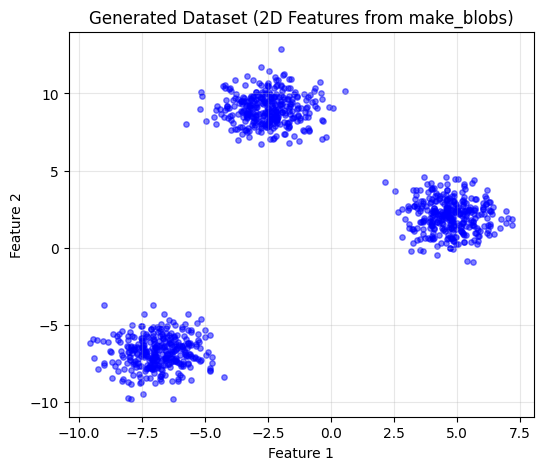

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler

# Generate dataset with 2 features and 1 label
X, Y = make_blobs(n_samples=1000, n_features=2, random_state=42)
Y = Y.reshape(-1, 1)  # ensure Y is column vector

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)  # fit and transform features

plt.figure(figsize=(6, 5))
plt.scatter(X[:, 0], X[:, 1], c='blue', alpha=0.5, s=15)
plt.title("Generated Dataset (2D Features from make_blobs)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.grid(alpha=0.3)
plt.show()


In [2]:

class GDRegressor:
    def __init__(self, lr=0.01, epochs=1000):
        # keep your initial values
        self.m = 29.19
        self.b = -100.0
        self.lr = lr
        self.epochs = epochs

    def fit(self, X, Y):
        """
        X: (n_samples, n_features)
        Y: (n_samples, 1) or (n_samples,)
        Model is y = m * x + b using the first column of X.
        """
        # use the first feature column because model has a single slope m
        x = X[:, 0].ravel()    # shape (n_samples,)
        y = np.asarray(Y).ravel()
        n = x.shape[0]

        for i in range(self.epochs):
            preds = self.m * x + self.b      # shape (n_samples,)
            error = y - preds                # shape (n_samples,)
            # gradients (for MSE loss L = mean((y - (mx+b))^2) )
            # dL/dm = -2/n * sum( (y - (mx+b)) * x )
            # dL/db = -2/n * sum( y - (mx+b) )
            loss_slope_m = -2.0 / n * np.sum(error * x)
            loss_slope_b = -2.0 / n * np.sum(error)
            
            # parameter updates
            self.m = self.m - self.lr * loss_slope_m
            self.b = self.b - self.lr * loss_slope_b
            
            # monitor loss occasionally:
            if (i+1) % (self.epochs // 10 or 1) == 0:
                loss = np.mean(error**2)
                print(f"Epoch {i+1}/{self.epochs} - loss: {loss:.6f}")

        return self.m, self.b

    def predict(self, X):
        x = np.asarray(X)[:, 0].ravel()
        return self.m * x + self.b


gd_model = GDRegressor(lr=0.01, epochs=1000)
gd_model.fit(X, Y)
print(f"Trained parameters: m = {gd_model.m:.6f}, b = {gd_model.b:.6f}")

# Quick test/prediction example
sample_X = np.array([[0.0, 0.0], [1.0, 2.0], [3.5, -1.2]])
preds = gd_model.predict(sample_X)
print("Sample inputs (first feature) -> predictions:", preds)



Epoch 100/1000 - loss: 238.963839
Epoch 200/1000 - loss: 6.770311
Epoch 300/1000 - loss: 0.739987
Epoch 400/1000 - loss: 0.583372
Epoch 500/1000 - loss: 0.579305
Epoch 600/1000 - loss: 0.579199
Epoch 700/1000 - loss: 0.579196
Epoch 800/1000 - loss: 0.579196
Epoch 900/1000 - loss: 0.579196
Epoch 1000/1000 - loss: 0.579196
Trained parameters: m = -0.060761, b = 0.904516
Sample inputs (first feature) -> predictions: [0.90451641 0.84375569 0.69185388]


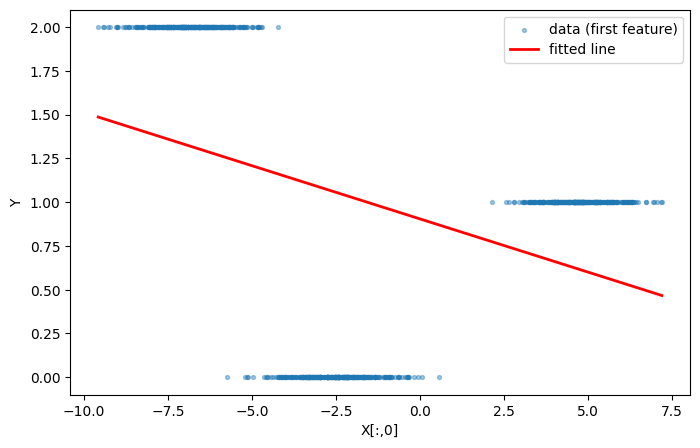

In [3]:
# plot data (first feature vs label) and fitted line
x = X[:, 0]
y = Y.ravel()
plt.figure(figsize=(8,5))
plt.scatter(x, y, s=8, alpha=0.4, label="data (first feature)")
xs = np.linspace(x.min(), x.max(), 200)
plt.plot(xs, gd_model.m * xs + gd_model.b, color="red", linewidth=2, label="fitted line")
plt.xlabel("X[:,0]")
plt.ylabel("Y")
plt.legend()
plt.show()



## **<font color="red">Complete Script</font>**

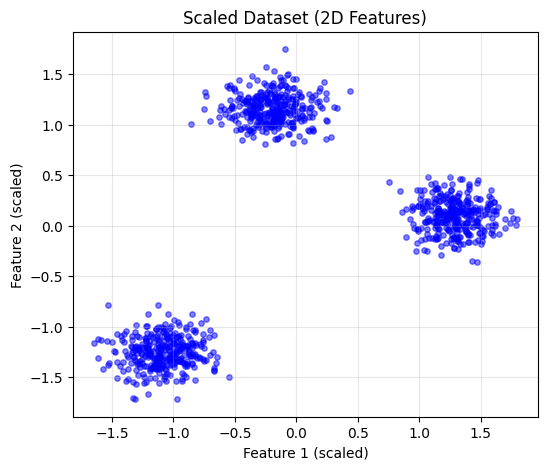

Epoch 100/1000 - loss: 203.310146
Epoch 200/1000 - loss: 4.144818
Epoch 300/1000 - loss: 0.641908
Epoch 400/1000 - loss: 0.580299
Epoch 500/1000 - loss: 0.579216
Epoch 600/1000 - loss: 0.579197
Epoch 700/1000 - loss: 0.579196
Epoch 800/1000 - loss: 0.579196
Epoch 900/1000 - loss: 0.579196
Epoch 1000/1000 - loss: 0.579196
Trained parameters: m = -0.296315, b = 0.999000
Sample inputs (first feature) -> predictions: [0.90451742 0.84375678 0.69185517]


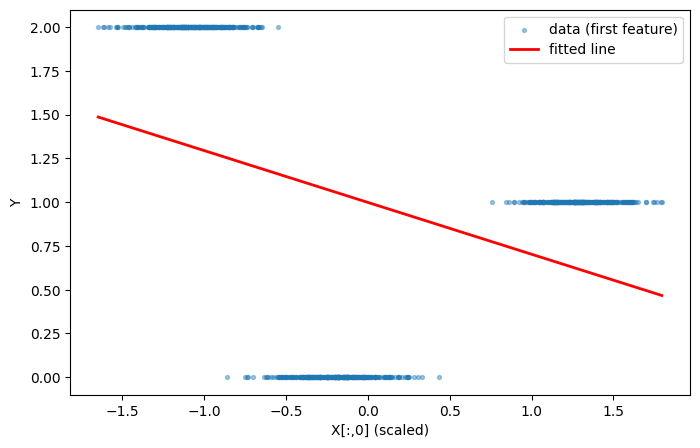

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler

# -----------------------
# Generate dataset
# -----------------------
X, Y = make_blobs(n_samples=1000, n_features=2, random_state=42)
Y = Y.reshape(-1, 1)  # ensure Y is column vector

# -----------------------
# Scale features
# -----------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)  # fit and transform features

# -----------------------
# Plot scaled dataset
# -----------------------
plt.figure(figsize=(6, 5))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c='blue', alpha=0.5, s=15)
plt.title("Scaled Dataset (2D Features)")
plt.xlabel("Feature 1 (scaled)")
plt.ylabel("Feature 2 (scaled)")
plt.grid(alpha=0.3)
plt.show()


# -----------------------
# Gradient Descent Regressor
# -----------------------
class GDRegressor:
    def __init__(self, lr=0.01, epochs=1000):
        self.m = 29.19
        self.b = -100.0
        self.lr = lr
        self.epochs = epochs

    def fit(self, X, Y):
        x = X[:, 0].ravel()    # use first feature
        y = np.asarray(Y).ravel()
        n = x.shape[0]

        for i in range(self.epochs):
            preds = self.m * x + self.b
            error = y - preds
            loss_slope_m = -2.0 / n * np.sum(error * x)
            loss_slope_b = -2.0 / n * np.sum(error)
            
            self.m = self.m - self.lr * loss_slope_m
            self.b = self.b - self.lr * loss_slope_b

            if (i+1) % (self.epochs // 10 or 1) == 0:
                loss = np.mean(error**2)
                print(f"Epoch {i+1}/{self.epochs} - loss: {loss:.6f}")

        return self.m, self.b

    def predict(self, X):
        x = np.asarray(X)[:, 0].ravel()
        return self.m * x + self.b


# -----------------------
# Train model on scaled data
# -----------------------
gd_model = GDRegressor(lr=0.01, epochs=1000)
gd_model.fit(X_scaled, Y)
print(f"Trained parameters: m = {gd_model.m:.6f}, b = {gd_model.b:.6f}")

# -----------------------
# Quick test/prediction example
# -----------------------
sample_X = np.array([[0.0, 0.0], [1.0, 2.0], [3.5, -1.2]])
# scale sample using the same scaler
sample_X_scaled = scaler.transform(sample_X)
preds = gd_model.predict(sample_X_scaled)
print("Sample inputs (first feature) -> predictions:", preds)

# -----------------------
# Plot data (first feature vs label) and fitted line
# -----------------------
x = X_scaled[:, 0]
y = Y.ravel()
plt.figure(figsize=(8,5))
plt.scatter(x, y, s=8, alpha=0.4, label="data (first feature)")
xs = np.linspace(x.min(), x.max(), 200)
plt.plot(xs, gd_model.m * xs + gd_model.b, color="red", linewidth=2, label="fitted line")
plt.xlabel("X[:,0] (scaled)")
plt.ylabel("Y")
plt.legend()
plt.show()


### **Animation of SDG**

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# --- Gradient Descent Regressor ---
class GDRegressor:
    def __init__(self, lr=0.01, epochs=200):
        self.m = 29.19
        self.b = -100.0
        self.lr = lr
        self.epochs = epochs
        self.history = []

    def fit(self, X, Y):
        x = X[:, 0].ravel()
        y = np.asarray(Y).ravel()
        n = x.shape[0]

        for i in range(self.epochs):
            preds = self.m * x + self.b
            error = y - preds

            loss_slope_m = -2.0 / n * np.sum(error * x)
            loss_slope_b = -2.0 / n * np.sum(error)

            self.m -= self.lr * loss_slope_m
            self.b -= self.lr * loss_slope_b

            self.history.append((self.m, self.b))

            if (i+1) % (self.epochs // 10 or 1) == 0:
                loss = np.mean(error**2)
                print(f"Epoch {i+1}/{self.epochs} - loss: {loss:.6f}")

        return self.m, self.b

    def predict(self, X):
        x = np.asarray(X)[:, 0].ravel()
        return self.m * x + self.b


# --- Create dataset ---
X, y = make_blobs(n_samples=100, n_features=2, centers=1, cluster_std=5.0, random_state=42)
y = y + 5 * np.random.randn(100)  # add some noise

# --- Train model ---
gd_model = GDRegressor(lr=0.01, epochs=200)
gd_model.fit(X, y)
print(f"Trained parameters: m = {gd_model.m:.6f}, b = {gd_model.b:.6f}")

# --- Animation ---
fig, ax = plt.subplots()
ax.scatter(X[:, 0], y, color='blue', label='Data points')
line, = ax.plot([], [], color='red', linewidth=2, label='Regression line')

ax.set_xlim(X[:, 0].min()-1, X[:, 0].max()+1)
ax.set_ylim(y.min()-5, y.max()+5)
ax.set_xlabel('Feature 0')
ax.set_ylabel('Label')
ax.set_title('Gradient Descent Regression')
ax.legend()

x_vals = np.array([X[:,0].min(), X[:,0].max()])

def init():
    line.set_data([], [])
    return line,

def update(frame):
    m, b = gd_model.history[frame]
    y_vals = m * x_vals + b
    line.set_data(x_vals, y_vals)
    return line,

ani = FuncAnimation(fig, update, frames=len(gd_model.history),
                    init_func=init, blit=True, interval=50, repeat=False)

# Display animation inline in JupyterLab
HTML(ani.to_jshtml())


Epoch 20/200 - loss: 3693.187245
Epoch 40/200 - loss: 2204.124458
Epoch 60/200 - loss: 1318.957785
Epoch 80/200 - loss: 792.774440
Epoch 100/200 - loss: 479.987118
Epoch 120/200 - loss: 294.052102
Epoch 140/200 - loss: 183.523869
Epoch 160/200 - loss: 117.820858
Epoch 180/200 - loss: 78.763999
Epoch 200/200 - loss: 55.546825
Trained parameters: m = -0.737406, b = -6.634005
